In [1]:
import warnings
warnings.filterwarnings("ignore")
import shutil
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn import preprocessing
import pandas as pd
#from multiprocessing import Process# this is used for multithreading
#import multiprocessing
#import random as r
#from xgboost import XGBClassifier
#from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans

In [2]:
        #### Step 1 ####
## Exploration and Analysis of the dataset ##

In [3]:
data1 = pd.read_csv('Payload_data_UNSW.csv')

In [4]:
data1.shape

(79881, 1505)

In [5]:
data1['label'].values

array(['analysis', 'analysis', 'analysis', ..., 'worms', 'worms', 'worms'],
      dtype=object)

In [6]:
data1['label'].astype("category")

0        analysis
1        analysis
2        analysis
3        analysis
4        analysis
           ...   
79876       worms
79877       worms
79878       worms
79879       worms
79880       worms
Name: label, Length: 79881, dtype: category
Categories (10, object): ['analysis', 'backdoor', 'dos', 'exploits', ..., 'normal', 'reconnaissance', 'shellcode', 'worms']

In [7]:
df = pd.DataFrame(data1)

In [8]:
df

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500,ttl,total_len,protocol,t_delta,label
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,254,100,others,0.000010,analysis
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,254,100,others,0.000005,analysis
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,254,90,others,0.000008,analysis
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,254,100,pipe,0.000004,analysis
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,254,90,others,0.000003,analysis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,254,459,tcp,0.000009,worms
79877,71,69,84,32,47,99,103,105,45,98,...,0,0,0,0,0,254,329,tcp,0.000007,worms
79878,80,79,83,84,32,47,98,108,111,103,...,0,0,0,0,0,254,471,tcp,0.000004,worms
79879,80,79,83,84,32,47,120,109,108,114,...,0,0,0,0,0,254,459,tcp,0.000009,worms


In [9]:
category_values = df.pivot_table(columns=['label'], aggfunc='size')

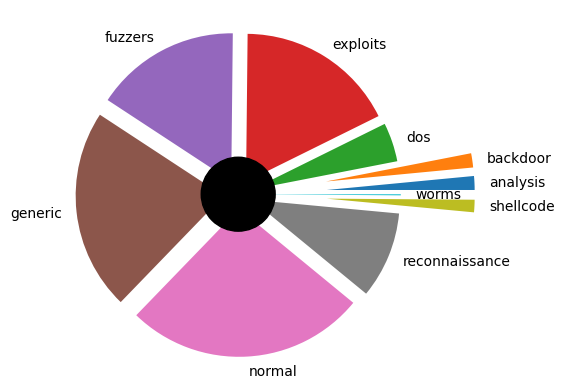

<Figure size 1200x1000 with 0 Axes>

In [10]:
df = pd.DataFrame(data1)
category_values = df.pivot_table(columns=['label'], aggfunc='size')

category_names = data1['label']
categories = category_names.unique()
categories.sort()
myexplode = [0.6, 0.6, 0.1, 0.1, 0.1, 0.1, 0.1,0.1, 0.6,0.1]# [Ana,Back,Dos,Exp,fu,gen,norm,recon,shell,worms]
plt.pie(category_values, labels=categories, explode=myexplode)
my_circle=plt.Circle( (0,0), 0.25, color='black')
p=plt.gcf()
fig = plt.figure(figsize =(12, 10))
p.gca().add_artist(my_circle)
plt.show()

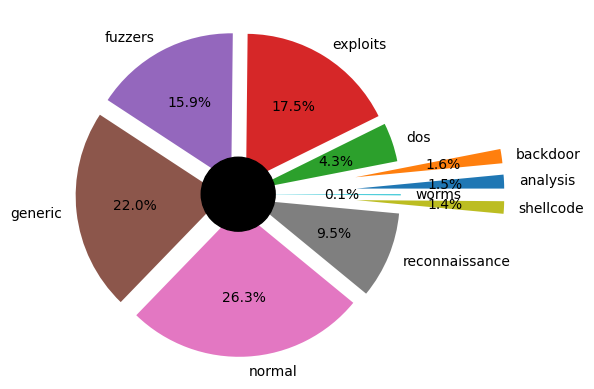

<Figure size 1200x1000 with 0 Axes>

In [11]:
df = pd.DataFrame(data1)
category_values = df.pivot_table(columns=['label'], aggfunc='size')
category_names = data1['label']
categories = category_names.unique()
categories.sort()
myexplode = [0.8, 0.8, 0.1, 0.1, 0.1, 0.1, 0.1,0.1, 0.8,0.1]# [Ana,Back,Dos,Exp,fu,gen,norm,recon,shell,worms]
plt.pie(category_values, labels=categories, explode=myexplode, autopct='%1.1f%%')
my_circle=plt.Circle( (0,0), 0.25, color='black')
p=plt.gcf()    
fig = plt.figure(figsize =(12, 10))
p.gca().add_artist(my_circle)
# Add the frequency values to the chart
#for i, label in enumerate(categories):
   # plt.text(0.3, (i / len(category_values)) + 0.5, '{}: {}'.format(label, category_values[i]), fontsize=10)
    
plt.show()

In [12]:
data1['protocol'].astype("category")

0        others
1        others
2        others
3          pipe
4        others
          ...  
79876       tcp
79877       tcp
79878       tcp
79879       tcp
79880       udp
Name: protocol, Length: 79881, dtype: category
Categories (41, object): ['arp', 'ax.25', 'crtp', 'crudp', ..., 'tcp', 'udp', 'unas', 'vmtp']

In [13]:
# ****Step 2 **** #
### Preprocessing ###

In [14]:
# Check for missing values using isnull()
#missing_values = df.isnull()
missing_values = df.isna() 
missing_values

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500,ttl,total_len,protocol,t_delta,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79876,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
79877,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
79878,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
79879,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
num_missing = missing_values.sum()
# Print the number of missing values in each column
print(num_missing)

payload_byte_1    0
payload_byte_2    0
payload_byte_3    0
payload_byte_4    0
payload_byte_5    0
                 ..
ttl               0
total_len         0
protocol          0
t_delta           0
label             0
Length: 1505, dtype: int64


In [16]:

# Read the CSV file into a dataframe, excluding the last 5 columns
#data2 = pd.read_csv('Payload_data_UNSW.csv', usecols=lambda x: x not in ['ttl', 'total_len','protocol','t_delta','label'])
#data2.shape

In [17]:
# Exclude the last 5 columns
df1= df.iloc[:, :-5]
df1.shape

(79881, 1500)

In [18]:
df1.head()

,payload_byte_1,payload_byte_2,payload_byte_3,payload_byte_4,payload_byte_5,payload_byte_6,payload_byte_7,payload_byte_8,payload_byte_9,payload_byte_10,...,payload_byte_1491,payload_byte_1492,payload_byte_1493,payload_byte_1494,payload_byte_1495,payload_byte_1496,payload_byte_1497,payload_byte_1498,payload_byte_1499,payload_byte_1500
0,66,80,83,33,32,55,98,32,66,80,...,0,0,0,0,0,0,0,0,0,0
1,66,80,83,33,32,53,52,32,66,80,...,0,0,0,0,0,0,0,0,0,0
2,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0
3,66,80,83,33,32,56,51,32,66,80,...,0,0,0,0,0,0,0,0,0,0
4,66,80,83,33,32,57,32,66,80,83,...,0,0,0,0,0,0,0,0,0,0


In [19]:

# Another method of Reading the CSV file into a dataframe, excluding the last 5 columns
#data2 = pd.read_csv('Payload_data_UNSW.csv', usecols=lambda x: x not in ['ttl', 'total_len','protocol','t_delta','label'])
#df1=pd.DataFrame(data2)
#df1.shape

In [20]:
#df1.iloc[:2,:10]

In [22]:
# Loop over the unique categories
user_input = input('Enter a category: ')
if user_input in df['label'].unique():
    ilocs = df.index[df['label'] == user_input].tolist()
    print(f"Category {user_input} is located at ilocs {ilocs}")
else:
    print('Please enter one of the following:  worms, dos, shellcode, fuzzers'),
    print('reconnaissance, normal, analysis, backdoor, exploits, generic')


Enter a category:  backdoor


Category backdoor is located at ilocs [1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342, 1343, 1344, 1345, 1346, 1347, 1348, 1349, 1350, 1351, 1352, 1353, 1354, 1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1

In [83]:
import random
# Loop over the unique categories
user_input = input('Enter a category: ')
if user_input in df['label'].unique():
    # Filter the rows with the current category and retrieve their ilocation
    ilocs = df.index[df['label'] == user_input].tolist()
    # randonly select the iloc from a given category
    instance= random.choice(ilocs) 
    #print(f"Category {user_input} is located at ilocs {ilocs}")
    print(f" Random instance from a label of type ' {user_input} ' is at ilocs= {instance}")
else:
    print('Please enter one of the following:  worms, dos, shellcode, fuzzers')
    print('reconnaissance, normal, analysis, backdoor, exploits, generic')


Enter a category:  normal


 Random instance from a label of type ' normal ' is at ilocs= 52557


52557


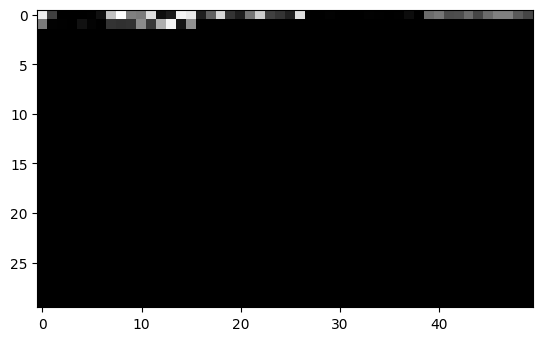

In [84]:
# Reading a row as an image 
row1 = df1.iloc[instance]
# Convert row to NumPy array and reshape into 2D matrix
arr1 = np.reshape(row1.values, (30,50))
# Display the image
print(instance)
plt.imshow(arr1, cmap='gray')
# Show the image
plt.show()

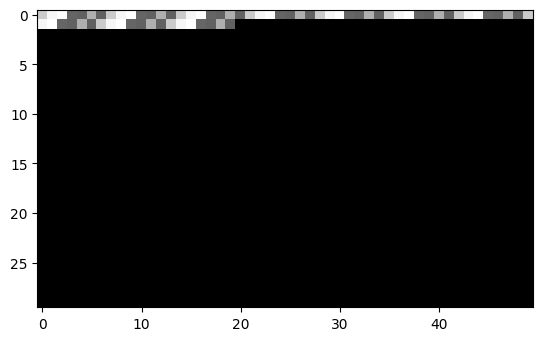

In [85]:
# Reading a row as an image[from backdoors sample]
row1 = df1.iloc[1208]
# Convert row to NumPy array and reshape into 2D matrix
arr1 = np.reshape(row1.values, (30, 50))
# Display the image
plt.imshow(arr1, cmap='gray')
# Show the image
plt.show()

In [86]:
# Loop over the unique categories
#for category in df['label'].unique():
#    # Filter the rows with the current category and retrieve their ilocation
#    ilocs = df.index[df['label'] == category].tolist()
#    print(f"Category {category} is located at ilocs {ilocs}")
#    print('*********************************************************************************')

In [87]:
inst=[]
value_shape=[]
user_input = input('Enter a category: ')
if user_input in df['label'].unique():
    ilocs = df.index[df['label'] == user_input].tolist()
    for i in range(1, 2500):
        row1=random.choice(ilocs)
        inst.append(row1)
        rows1=df1.iloc[(row1)]
        value_shape.append(np.reshape(rows1.values,(30,50)))

Enter a category:  normal


In [88]:
print("")
print(inst[:30])
print("***********************************************")
print("")
print(value_shape[0])
print("")
print("")
#print(value_shape[:2])


[64869, 61564, 58093, 58890, 50732, 59540, 68319, 56121, 58448, 66491, 67541, 59566, 70928, 56029, 52216, 61178, 60242, 56034, 54017, 54398, 56759, 54806, 55327, 68956, 52545, 60618, 53111, 58202, 69782, 51843]
***********************************************

[[ 57  32 108 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]




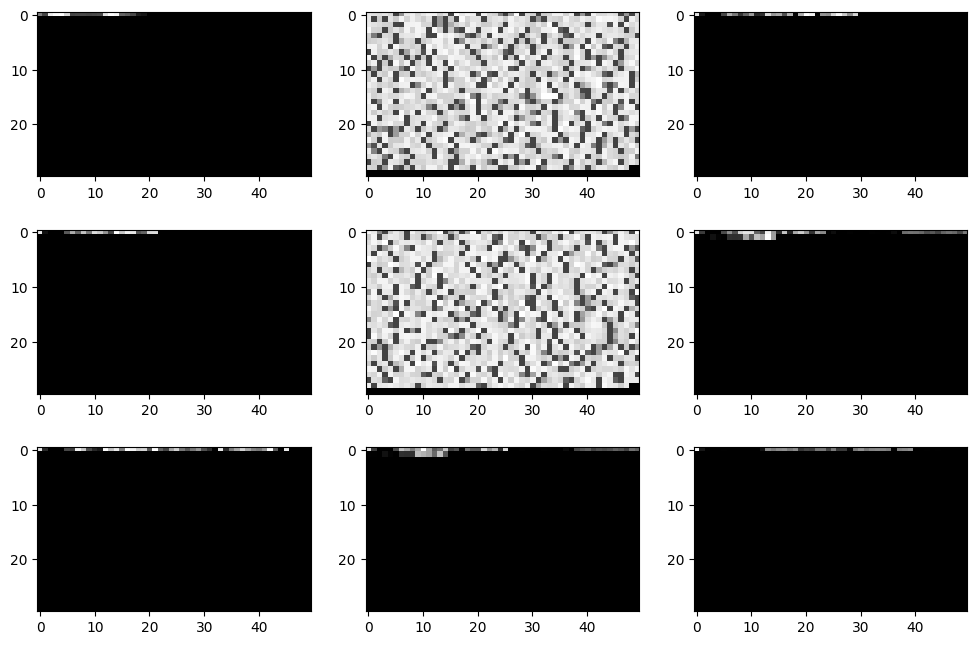

In [112]:

#selection = set(random.choice(items, 10))
w = 15
h = 10
fig = plt.figure(figsize=(12,8))
columns = 3
rows = 3
for i in range(1, columns*rows +1):
    #row11 =random.choice(value_shape)
    row11 = value_shape[i-1]
    fig.add_subplot(rows,columns,i)
    plt.imshow(row11,cmap='gray')
plt.show()

In [90]:
print(inst[:5])

[64869, 61564, 58093, 58890, 50732]


In [97]:
#print(random.choice(inst))
print(inst[5])

59540


In [92]:
#print(pd.DataFrame(value_shape[6]).head())
#print(row11)

In [98]:
print(value_shape[5])

[[227  60   0 ... 105  72 119]
 [  2   1   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


In [94]:
print(value_shape[1])

[[110 107 105 ...  73  32 103]
 [111  32  97 ...  32 114 101]
 [112 108 105 ... 115 104 111]
 ...
 [ 32  98 101 ... 100 111 100]
 [103 101  32 ... 101   0   0]
 [  0   0   0 ...   0   0   0]]


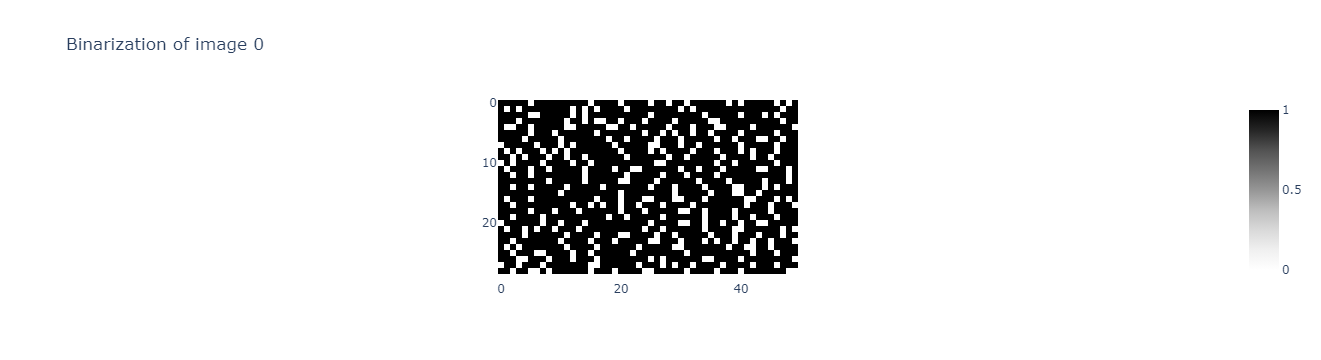

In [99]:
from gtda.images import Binarizer
# Pick out index of first image
#im8_idx = np.flatnonzero(value_shape)[7]
# Reshape to (n_samples, n_pixels_x, n_pixels_y) format
shaped = value_shape[1][None, :, :]
binarizer = Binarizer(threshold=0.5)
shape_binarized = binarizer.fit_transform(shaped)
binarizer.plot(shape_binarized)
#print(im8_idx)

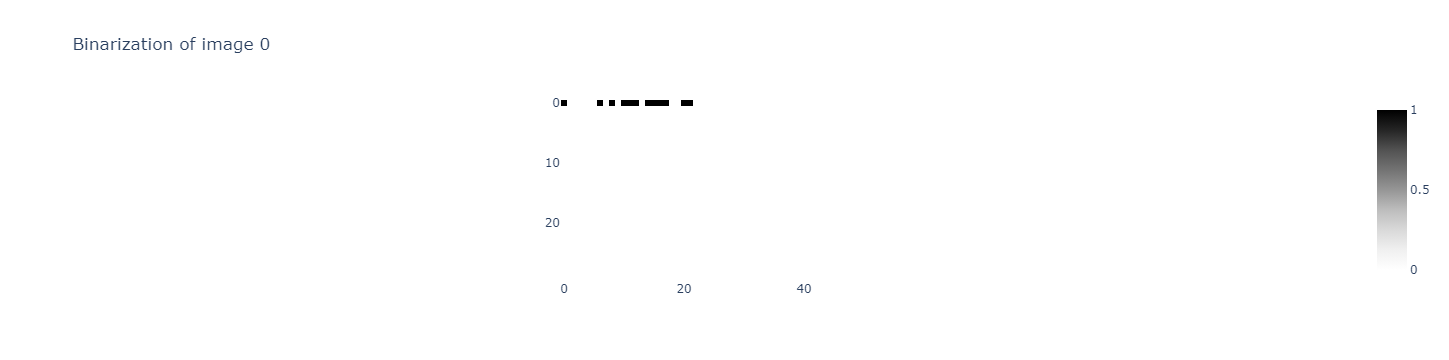

In [101]:
im1 = value_shape[3][None, :, :]
binarizer = Binarizer(threshold=0.5)
im1_binarized = binarizer.fit_transform(im1)
binarizer.plot(im1_binarized)
#print(im8)
#value_shape[3]

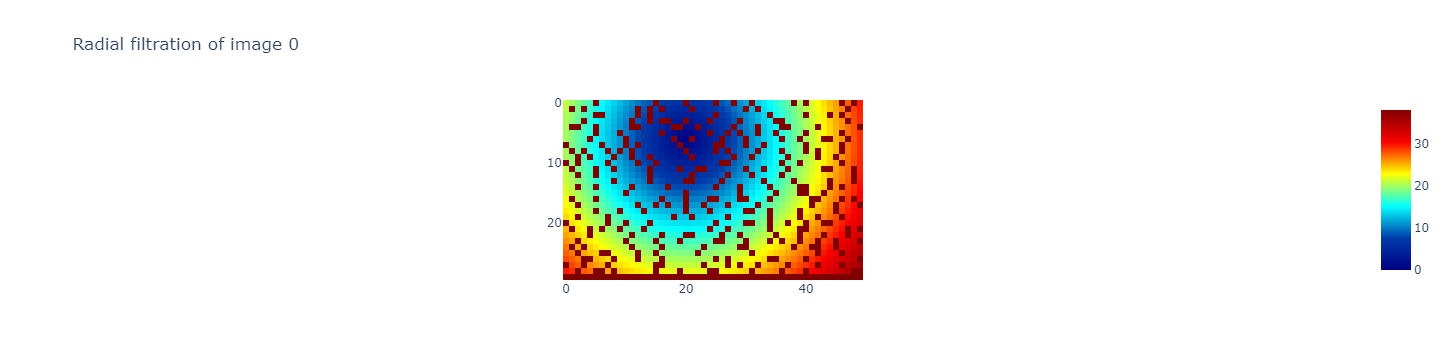

In [102]:
from gtda.images import RadialFiltration

radial_filtration = RadialFiltration(center=np.array([20, 6]))
im8_filtration = radial_filtration.fit_transform(shape_binarized)
radial_filtration.plot(im8_filtration, colorscale="jet")##17647

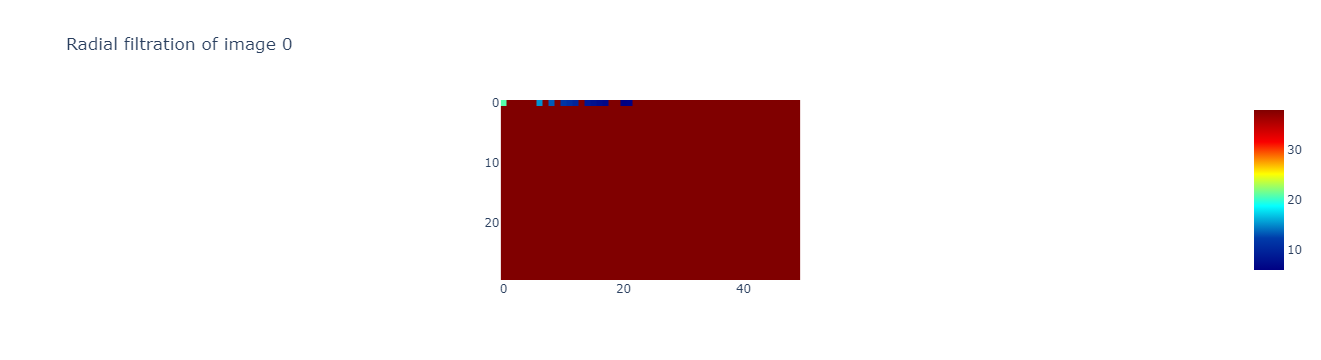

In [103]:
im1_filtration = radial_filtration.fit_transform(im1_binarized)
radial_filtration.plot(im1_filtration, colorscale="jet")##17647

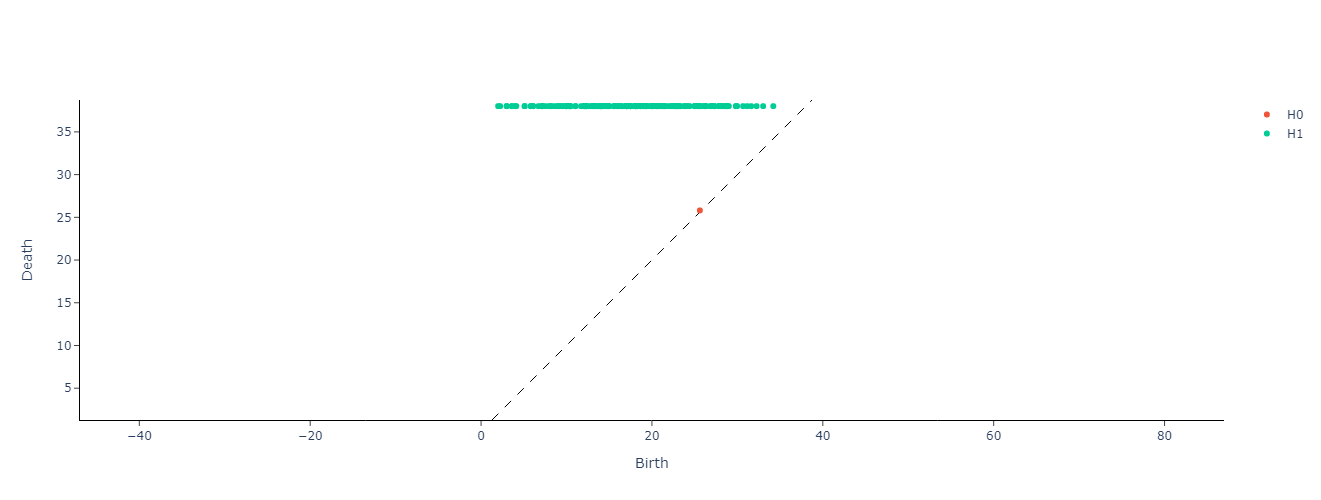

In [104]:
from gtda.homology import CubicalPersistence
#from gtda.plotting import PersistencePlot
cubical_persistence = CubicalPersistence(n_jobs=-1)
im8_cubical = cubical_persistence.fit_transform(im8_filtration)
#im1_cubical = cubical_persistence.fit_transform(im1_filtration)
# plot persistence diagrams on the same graph
3#plot = PersistencePlot(show=False)
#plot=cubical_persistence.plot(show=False)
#plot.plot(im1_cubical, label='Image 1')
#plot.plot(im8_cubical, label='Image 2')
#plot.show()
cubical_persistence.plot(im8_cubical)

In [114]:
from gtda.plotting  import plot_betti_curves

In [130]:
# this code here is not par of the main code 
import numpy as np
from gtda.homology import CubicalPersistence
from gtda.plotting import plot_betti_curves
import matplotlib.pyplot as plt

# Generate a random binary image
#image = np.random.randint(0, 2, size=(50, 50))

# Compute the cubical complex
cp = CubicalPersistence(homology_dimensions=[0,1])
diag = cp.fit_transform(im1)
diag

In [135]:
diag.shape

(1, 2, 3)

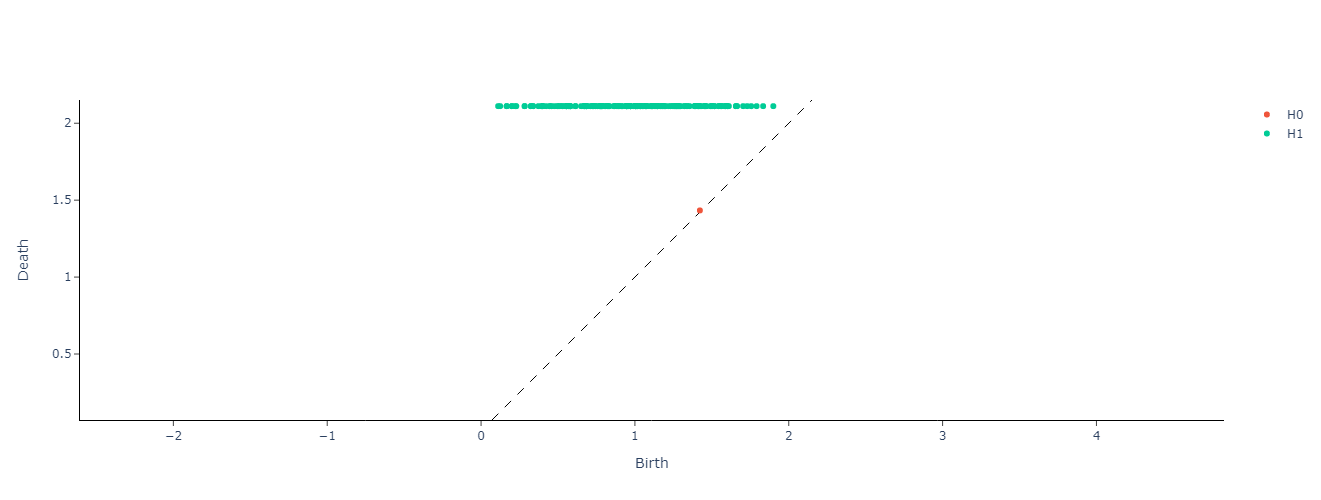

In [124]:
from gtda.diagrams import Scaler

scaler = Scaler()
im8_scaled = scaler.fit_transform(im8_cubical)

scaler.plot(im8_scaled)

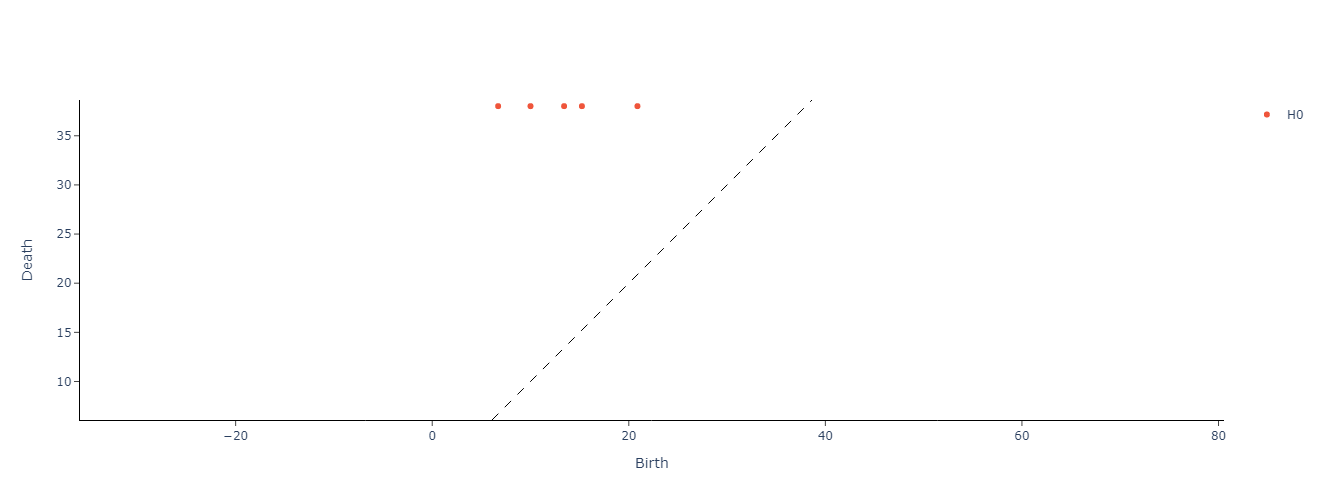

In [106]:
from gtda.homology import CubicalPersistence
cubical_persistence = CubicalPersistence(n_jobs=-1)
im1_cubical = cubical_persistence.fit_transform(im1_filtration)
im8_cubical = cubical_persistence.fit_transform(im8_filtration)
cubical_persistence.plot(im1_cubical)
#cubical_persistence.plot(im8_cubical)

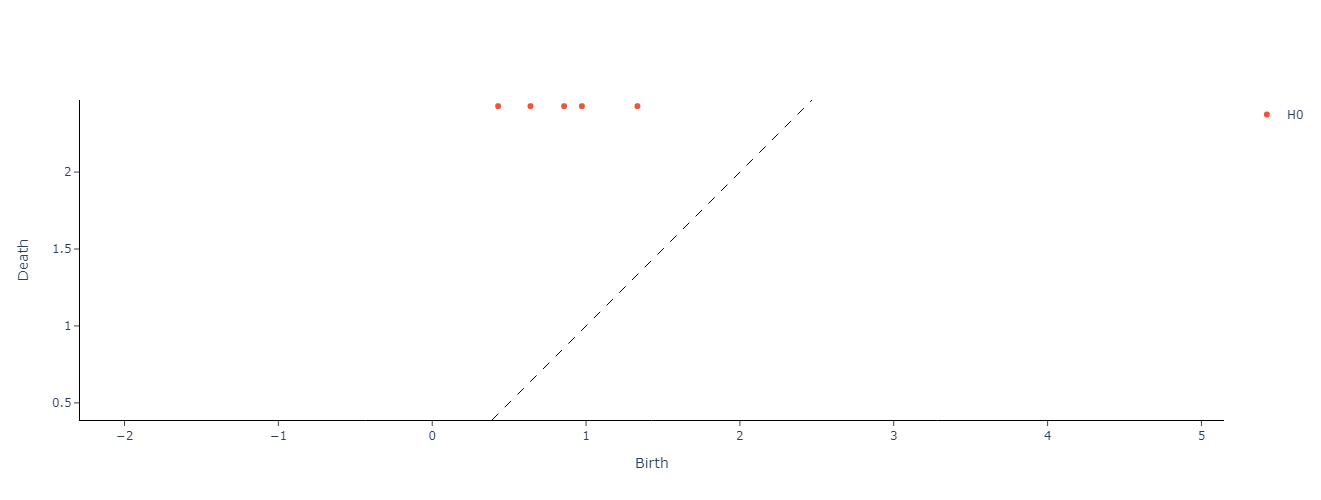

In [107]:
from gtda.diagrams import Scaler

scaler = Scaler()
im1_scaled = scaler.fit_transform(im1_cubical)

scaler.plot(im1_scaled)

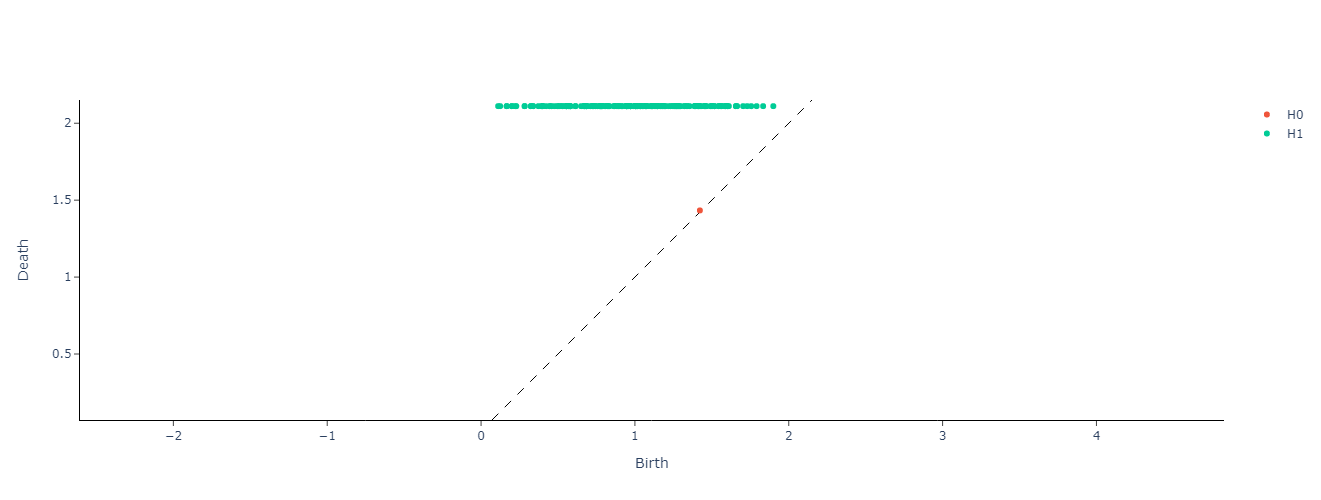

In [108]:
im8_scaled = scaler.fit_transform(im8_cubical)

scaler.plot(im8_scaled)

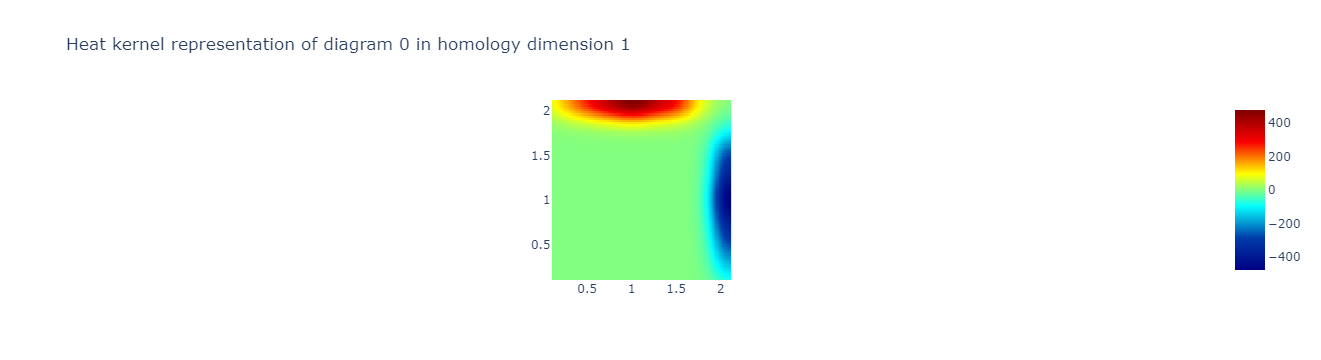

In [111]:
from gtda.diagrams import HeatKernel

heat = HeatKernel(sigma=.15, n_bins=81, n_jobs=-1)
im1_heat = heat.fit_transform(im8_scaled)

# Visualise the heat kernel for H1
heat.plot(im1_heat, homology_dimension_idx=1, colorscale='jet')

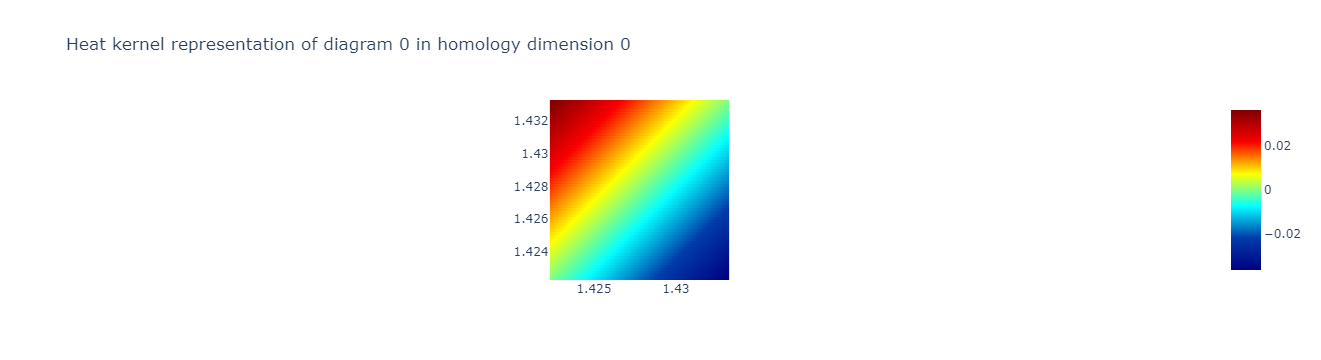

In [110]:
heat = HeatKernel(sigma=.15, n_bins=60, n_jobs=-1)
im8_heat = heat.fit_transform(im8_scaled)

# Visualise the heat kernel for H1
heat.plot(im8_heat, homology_dimension_idx=0, colorscale='jet')

In [450]:
from sklearn.pipeline import Pipeline
from gtda.diagrams import Amplitude

steps = [
    ("binarizer", Binarizer(threshold=0.4)),
    ("filtration", RadialFiltration(center=np.array([20, 6]))),
    ("diagram", CubicalPersistence()),
    ("rescaling", Scaler()),
    ("amplitude", Amplitude(metric="heat", metric_params={'sigma':0.15, 'n_bins':60}))
]

heat_pipeline =Pipeline(steps)

In [451]:
steps #print(Pipeline(steps))


[('binarizer', Binarizer(threshold=0.4)),
 ('filtration', RadialFiltration(center=array([20,  6]))),
 ('diagram', CubicalPersistence()),
 ('rescaling', Scaler()),
 ('amplitude',
  Amplitude(metric='heat', metric_params={'n_bins': 60, 'sigma': 0.15}))]

In [452]:
im8_pipeline = heat_pipeline.fit_transform(shaped)
im8_pipeline

array([[ 3.39400754, 23.23577604]])

In [453]:
im1 = value_shape[3][None, :, :]
im1_pipeline = heat_pipeline.fit_transform(im1)
im1_pipeline

array([[ 2.66287382, 27.68211129]])

In [454]:
from sklearn import set_config
set_config(display='diagram')

In [455]:
heat_pipeline

Pipeline(steps=[('binarizer', Binarizer(threshold=0.4)),
                ('filtration', RadialFiltration(center=array([20,  6]))),
                ('diagram', CubicalPersistence()), ('rescaling', Scaler()),
                ('amplitude',
                 Amplitude(metric='heat',
                           metric_params={'n_bins': 60, 'sigma': 0.15}))])

In [425]:
df1= df.iloc[:, :-5]
df1.shape
xtrain1=df1

In [426]:
xtrain1.shape


(79881, 1500)

In [482]:
xtrain.iloc[0:1,:1499]
ytrain=df.iloc[:,1504:]

In [ ]:
xtrain1.shape
xtrain1[1]

In [487]:
ytrain.iloc[0]

label    analysis
Name: 0, dtype: object

In [486]:
ytrain.head()

,label
0,analysis
1,analysis
2,analysis
3,analysis
4,analysis


In [490]:
x_train=np.array(value_shape)
x_train.shape

(2499, 30, 50)

In [488]:
x_train[:2]


array([[[254, 255, 255, ..., 208, 254, 255],
        [255,  81, 106, ...,  76, 254, 255],
        [255, 129, 226, ...,  75,  67,  75],
        ...,
        [  8, 139,  81, ...,  82, 255, 149],
        [192, 254, 255, ..., 254, 255, 255],
        [139, 133,  76, ...,   0,   0,   0]],

       [[ 71,  69,  84, ...,  59, 101,  99],
        [104, 111,  37, ...,  49,  56,  37],
        [ 50, 102, 108, ...,  37,  50,  48],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]]])

In [489]:
#im1 = value_shape[3][None, :, :]
#im1_pipeline = heat_pipeline.fit_transform(x_train[2][None,:,:])
im1_pipeline = heat_pipeline.fit_transform(x_train[:22])
im1_pipeline.shape
#x_train[:22].shape

(22, 2)

In [491]:
#im1_pipeline=np.array(im1_pipeline)
im1_pipeline.shape
(im1_pipeline[:10,:2])#.shape


array([[  4.71357478, 168.36563976],
       [ 27.67431875,   2.15523444],
       [  7.15882808,  26.6653822 ],
       [ 27.67431875,   2.15523444],
       [ 35.80245473,  35.87707045],
       [ 14.6841134 ,  13.23830793],
       [ 16.5488094 ,  12.08126994],
       [ 26.7242608 , 112.20860018],
       [ 14.2310709 ,  10.85867089],
       [ 35.80245473,  35.87707045]])

In [492]:
x_train[2].shape

(30, 50)

In [446]:
im8_heat
im8_heat.shape

(1, 2, 60, 60)